<a href="https://colab.research.google.com/github/gaelosvaldor-star/Simulaci-n-2-/blob/main/Metropolis_Hastings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulación mediante el algoritmo de Metrópolis-Hastings

**Alumno:** Gael Osvaldo Rosales de la Cruz
**Materia:** Investigación de Operaciones
**Maestro:** Ricardo Medel Esquivel

El objetivo de este algoritmo es implementar mediante simulación el algoritmo de Metrópolis-Hastings para generar muestras de una distribución de probabilidad bidimensional definida por la función objetivo $f(x_1, x_2)$.

Se busca analizar el comportamiento y la convergencia de diferentes cadenas de Markov iniciadas en distintos puntos, así como comprobar gráficamente que las muestras generadas por el algoritmo se concentran en las regiones donde la función objetivo presenta mayor densidad.

Para ello se utilizarán gráficas de las cadenas, un mapa de calor de la función objetivo y una representación de las muestras obtenidas mediante la simulación.

## EJERCICIO

Se desea simular mediante el algoritmo de Metrópolis-Hastings una distribución de probabilidad bidimensional cuya función de densidad es proporcional a:

$$f(x_1, x_2) = C \exp \left[ -\frac{x_1^2 x_2^2 + x_1^2 + x_2^2 - 8x_1 - 8x_2}{2} \right]$$

Para realizar la simulación se utilizará una distribución propuesta normal, aprovechando que es una distribución simétrica. Por lo tanto, la probabilidad de aceptación se puede expresar como:

$$\alpha(X, Y) = \min \left\{ 1, \frac{\pi(Y)}{\pi(X)} \right\}$$

Se generarán diferentes cadenas de Markov a partir de distintos valores iniciales para observar su comportamiento y analizar gráficamente su convergencia hacia la distribución objetivo.

## Metodología

Se utilizará el algoritmo de Metrópolis-Hastings mediante una caminata aleatoria.

El procedimiento es el siguiente:

1. Se establece un punto inicial $X_0 = (x_1, x_2)$.
2. Se genera un candidato $Y$ a partir de una distribución normal:

$$Y \sim N(X_t, \sigma^2 I)$$

3. Se calcula la probabilidad de aceptación:

$$\alpha(X_t, Y) = \min \left\{ 1, \frac{\pi(Y)}{\pi(X_t)} \right\}$$

4. Se genera un número aleatorio:

$$U \sim U(0, 1)$$

5. Si:

$$U \le \alpha(X_t, Y)$$

se acepta el candidato:

$$X_{t+1} = Y$$

En caso contrario, se conserva el estado anterior:

$$X_{t+1} = X_t$$

6. El procedimiento se repite durante un número determinado de iteraciones.

Las muestras obtenidas forman una cadena de Markov cuya distribución estacionaria corresponde a la distribución objetivo.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

In [3]:
def target(x):

    x1 = x[0]
    x2 = x[1]

    return np.exp(
        -(x1**2 * x2**2 + x1**2 + x2**2 - 8*x1 - 8*x2) / 2
    )


# ==========================================================
# ALGORITMO METROPOLIS-HASTINGS
# ==========================================================

def metropolissampler(niters, x0, sigma):

    # Matriz donde guardaremos x1 y x2
    samples = np.zeros((niters + 1, 2))

    # Punto inicial
    x = np.array(x0, dtype=float)

    samples[0] = x

    aceptadas = 0

    for i in range(niters):
# --------------------------------------------------
        # Paso 1: generar candidato
        # Y ~ N(Xt, sigma^2)
        # --------------------------------------------------

        x_p = x + np.random.normal(0, sigma, 2)

        # --------------------------------------------------
        # Paso 2: calcular probabilidad de aceptación
        # --------------------------------------------------

        fx = target(x)
        fx_p = target(x_p)

        alpha = min(1, fx_p / fx)

        # --------------------------------------------------
        # Paso 3: generar U ~ Uniforme(0,1)
        # --------------------------------------------------

        u = np.random.uniform()

        # --------------------------------------------------
        # Paso 4: aceptar o rechazar
        # --------------------------------------------------

        if u < alpha:
            x = x_p
            aceptadas += 1

        # Guardar estado de la cadena
        samples[i + 1] = x

    tasa_aceptacion = aceptadas / niters

    return samples, tasa_aceptacion

# ==========================================================
# SIMULACIÓN
# ==========================================================

niters = 50000
sigma = 0.5

# Tres puntos iniciales
puntos_iniciales = [
    [0.01, 0.01],
    [0.3, 0.3],
    [0.5, 0.5]
]

cadenas = []

for punto in puntos_iniciales:

    cadena, tasa = metropolissampler(
        niters,
        punto,
        sigma
    )

    cadenas.append(cadena)

    print(
        "Punto inicial:", punto,
        " | Tasa de aceptación:", round(tasa, 4)
    )



Punto inicial: [0.01, 0.01]  | Tasa de aceptación: 0.5228
Punto inicial: [0.3, 0.3]  | Tasa de aceptación: 0.5202
Punto inicial: [0.5, 0.5]  | Tasa de aceptación: 0.5169


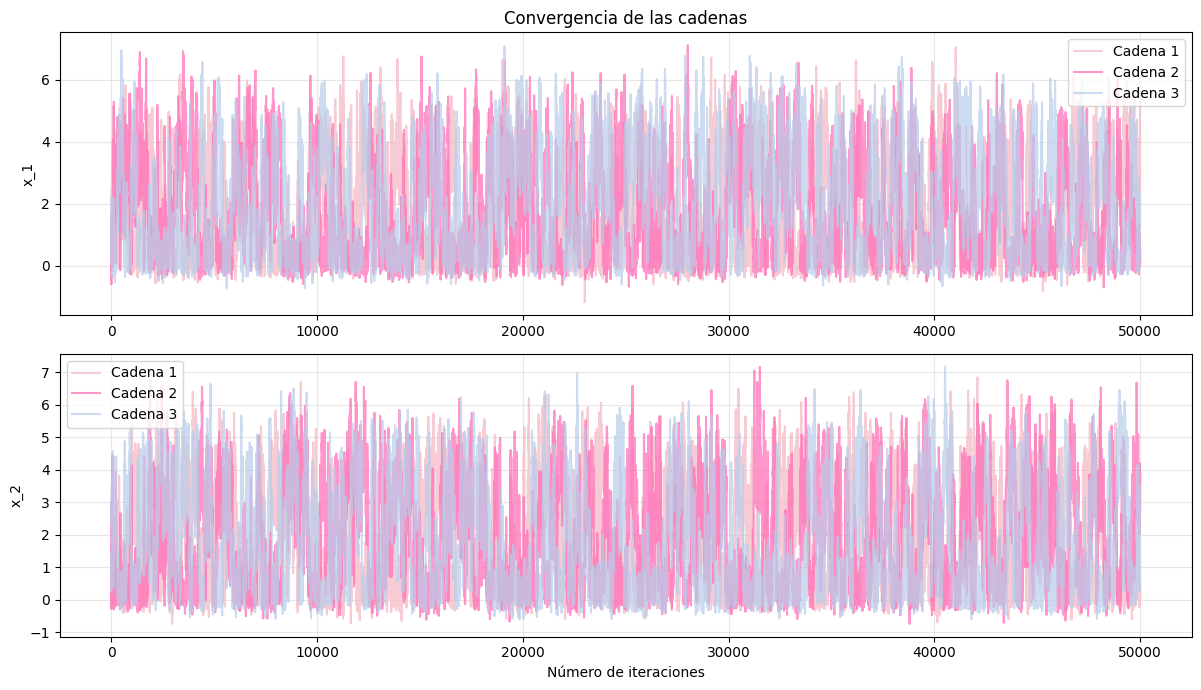

In [5]:
plt.figure(figsize=(12, 7))
colores = ["#F4B6C2", "hotpink", "#B8CDEB", "#C5E1C5"]

for i in range(len(cadenas)):

    plt.subplot(2, 1, 1)
    plt.plot(
        cadenas[i][:, 0],
        alpha=0.7,
        color=colores[i],
        label="Cadena " + str(i + 1)
    )

plt.ylabel("x_1")
plt.title("Convergencia de las cadenas")
plt.legend()
plt.grid(alpha=0.3)


plt.subplot(2, 1, 2)

for i in range(len(cadenas)):

    plt.plot(
        cadenas[i][:, 1],
        alpha=0.7,
        color=colores[i],
        label="Cadena " + str(i + 1)
    )

plt.xlabel("Número de iteraciones")
plt.ylabel("x_2")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

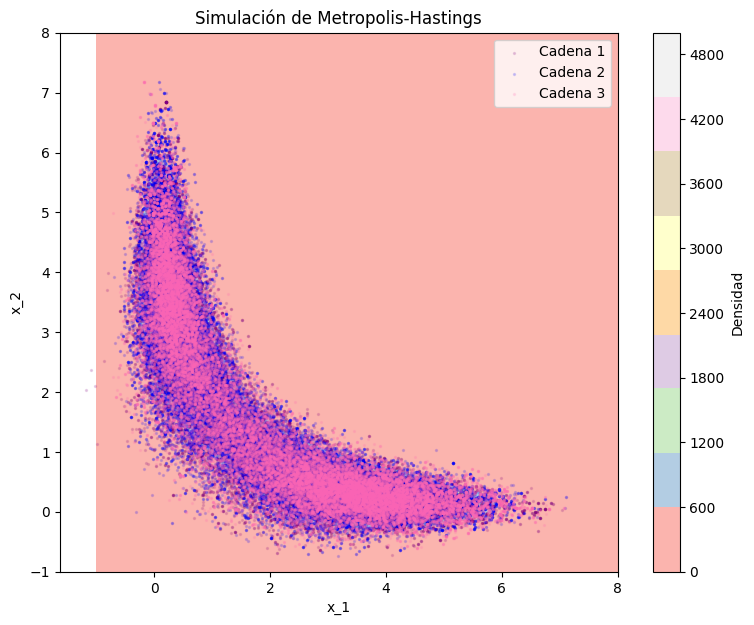

In [7]:
# Definir la rejilla (grid) para evaluar la función objetivo
x1_grid = np.linspace(-1, 8, 200)
x2_grid = np.linspace(-1, 8, 200)
X1, X2 = np.meshgrid(x1_grid, x2_grid)

# Evaluar la función objetivo en el grid
Z = np.zeros_like(X1)
for idx in range(X1.shape[0]):
    for idy in range(X1.shape[1]):
        Z[idx, idy] = target([X1[idx, idy], X2[idx, idy]])

plt.figure(figsize=(9, 7))
colores = ["purple", "blue", "hotpink", "green"]

# Función objetivo
plt.contourf(
    X1,
    X2,
    Z,
    levels=50,
    cmap='Pastel1'
)

plt.colorbar(label="Densidad")

# Graficar las muestras
for i in range(len(cadenas)):
    plt.scatter(
        cadenas[i][5000:, 0],
        cadenas[i][5000:, 1],
        s=2,
        alpha=0.15,
        color=colores[i],
        label="Cadena " + str(i + 1)
    )

plt.xlabel("x_1")
plt.ylabel("x_2")
plt.title("Simulación de Metropolis-Hastings")
plt.legend()

plt.show()

## Conclusión

La simulación permitió implementar exitosamente el algoritmo de Metrópolis-Hastings para extraer muestras de una distribución de probabilidad bidimensional compleja cuya función de densidad solo se conoce de manera proporcional, evitando la necesidad de calcular la constante de normalización analíticamente.

Mediante la inicialización de múltiples cadenas de Markov a partir de distintos puntos en el espacio, fue posible analizar su convergencia y estabilidad. A través de las gráficas de trayectoria y el mapa de calor superpuesto con las muestras, se comprobó visualmente que las cadenas convergen y que las muestras generadas se concentran de manera efectiva en las regiones de mayor densidad de la distribución objetivo.

En conclusión, este método demostró ser una herramienta computacional robusta y eficiente para la simulación de distribuciones multivariadas avanzadas, superando las limitaciones de los métodos tradicionales de muestreo directo y validando su utilidad práctica en la modelación estocástica.